In [2]:
import numpy as np

def leave_m_out(n, m):
    indices = np.arange(n)
    np.random.shuffle(indices)
    test_indices = indices[:m]
    train_indices = indices[m:]
    return test_indices, train_indices


In [3]:
import numpy as np
from scipy.sparse import csr_matrix, hstack

def divide_data2(ratings):
    ratings = ratings / 5.0
    N, M = ratings.shape
    Train = [] # Initialize as empty list
    Test = []  # Initialize as empty list

    for j in range(M):
        col_ratings = ratings[:, j]
        I = np.where(col_ratings != 0)[0]
        Val = col_ratings[I]

        if len(I) < 5:
            test_indices, train_indices = leave_m_out(len(I), len(I))
        else:
            test_indices, train_indices = leave_m_out(len(I), 5)

        I_train = I[train_indices]
        Val_train = Val[train_indices]
        Train.append(csr_matrix((Val_train, (I_train, np.zeros_like(I_train))), shape=(N, 1))) # Append to list

        I_test = I[test_indices]
        Val_test = Val[test_indices]
        Test.append(csr_matrix((Val_test, (I_test, np.zeros_like(I_test))), shape=(N, 1))) # Append to list

    # Changed the following lines to correctly stack the sparse matrices
    Train_matrix = hstack(Train) # Use hstack from scipy.sparse
    Test_matrix = hstack(Test)  # Use hstack from scipy.sparse
    return Train_matrix, Test_matrix

In [4]:
def update_mu_values(C, D, phi_x, mu, t):
    col = C.shape[1] // 6  # Assuming C has columns divisible by 6

    # Partition C into six parts
    C1 = C[:, :col] / np.sqrt(mu[0])
    C2 = C[:, col:2*col] / np.sqrt(mu[1])
    C3 = C[:, 2*col:3*col] / np.sqrt(mu[2])
    C4 = C[:, 3*col:4*col] / np.sqrt(mu[3])
    C5 = C[:, 4*col:5*col] / np.sqrt(mu[4])
    C6 = C[:, 5*col:] / np.sqrt(mu[5])

    # Compute h1 to h6
    h_values = np.array([
        np.sum((phi_x[i] - D.T @ C_part) ** 2)
        for i, C_part in enumerate([C1, C2, C3, C4, C5, C6])
    ])

    # Compute new mu values
    mu_values = (1 / h_values) ** (1 / (t - 1))
    mu_values /= np.sum(mu_values)

    return mu_values

In [5]:
import numpy as np

def DCDmex(b, MM, Ms, x, maxItr):
    """
    Python equivalent of the given MEX function.
    :param b: (numpy array) N x D matrix
    :param MM: (numpy array) N x knn matrix
    :param Ms: (numpy array) K x D matrix
    :param x: (numpy array) vector of size D
    :param maxItr: (int) maximum number of iterations
    """
    r = MM.shape[1]  # Number of columns in MM
    it = 0
    converge = False

    while not converge:
        no_change_count = 0

        for k in range(r):
            ss = 0
            for i in range(r):
                if i != k:
                    ss += MM[k, i] * b[i]
            ss -= Ms[k] + x[k]

            if isinstance(ss, np.ndarray):
                if np.all(ss > 0):  # Check if all elements of ss are greater than 0
                    if b[k] == -1:
                        no_change_count += 1
                    else:
                        b[k] = -1
                elif np.all(ss < 0): # Check if all elements of ss are less than 0
                    if b[k] == 1:
                        no_change_count += 1
                    else:
                        b[k] = 1
                else:
                    no_change_count += 1
            else:  # If ss is a single value
                if ss > 0:
                    if b[k] == -1:
                        no_change_count += 1
                    else:
                        b[k] = -1
                elif ss < 0:
                    if b[k] == 1:
                        no_change_count += 1
                    else:
                        b[k] = 1
                else:
                    no_change_count += 1

        if it >= maxItr - 1 or no_change_count == r:
            converge = True

        it += 1

    return b


In [6]:
def ScaleScore(s, scale, maxS, minS):
    """
    Scale the scores in a user-item rating matrix to [-scale, +scale].

    Parameters:
        s (numpy array or list): Input scores to be scaled.
        scale (float): The target scaling factor.
        maxS (float): Maximum value in the original score range.
        minS (float): Minimum value in the original score range.

    Returns:
        numpy array: Scaled scores.
    """
    s = np.array(s)  # Ensure input is a NumPy array
    s = (s - minS) / (maxS - minS)  # Normalize to [0,1]
    s = 2 * scale * s - scale  # Scale to [-scale, +scale]
    return s

In [7]:
def my_mgs(Q, b):
    Q, _ = np.linalg.qr(Q)
    if Q.shape[1] < b:
        extra = b - Q.shape[1]
        random_vectors = np.random.randn(Q.shape[0], extra)
        Q_extra, _ = np.linalg.qr(random_vectors - Q @ (Q.T @ random_vectors))
        Q = np.hstack([Q, Q_extra[:, :extra]])
    return Q[:, :b]

def UpdateSVD(W):
    b, n = W.shape
    m = np.mean(W, axis=1, keepdims=True)
    JW = W - m  # Centering
    JW = JW.T  # Transpose

    eigvals, P = np.linalg.eigh(JW.T @ JW)
    eigvals = np.maximum(eigvals, 0)

    zero_idx = eigvals <= 1e-10
    if np.sum(zero_idx) == 0:
        H_v = np.sqrt(n) * P @ (JW @ P @ np.diag(1.0 / np.sqrt(eigvals))).T
    else:
        eigvals = eigvals[~zero_idx]
        Q = JW @ P[:, ~zero_idx] @ np.diag(1.0 / np.sqrt(eigvals))
        Q = my_mgs(Q, b)  # Ensure Q has b columns
        # print("DEBUG -- Shapes before matmul:")
        # print("P shape:", P.shape)
        # print("Q shape:", Q.shape)
        # print("Q.T shape:", Q.T.shape)

        H_v = np.sqrt(n) * P @ Q.T

    return H_v

In [8]:
import numpy as np
from scipy.sparse import csr_matrix

def l2_norm_row(X):
    """
    Normalizes the rows of X to unit L2 norm.

    Parameters:
        X (numpy array): Input matrix.

    Returns:
        numpy array: Row-normalized matrix.
    """
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + np.finfo(float).eps)

def construct_A(X, k, binary):
    """
    Constructs an adjacency matrix based on the nearest neighbor graph.

    Parameters:
        X (numpy array): Data matrix where each row is a point.
        k (int): Number of nearest neighbors to include in the graph.
        binary (bool): If True, adjacency matrix contains only binary values;
                       otherwise, it contains cosine similarity values.

    Returns:
        scipy.sparse.csr_matrix: Adjacency matrix.
    """
    n = X.shape[0]

    # Compute cosine similarity
    X = l2_norm_row(X)
    S = X @ X.T  # Cosine similarity matrix

    # Find k nearest neighbors (excluding self)
    inds = np.argsort(-S, axis=1)[:, 1:k+1]  # Sort in descending order, exclude self
    vals = np.sort(S, axis=1)[:, -k:]  # Corresponding cosine similarity values

    # Construct adjacency matrix
    row_idx = np.repeat(np.arange(n), k)
    col_idx = inds.ravel()
    data = vals.ravel()

    A = csr_matrix((data, (row_idx, col_idx)), shape=(n, n))

    # Ensure symmetry
    A = A.maximum(A.T)

    if binary:
        A.data = np.ones_like(A.data)  # Convert to binary adjacency matrix

    return A.toarray()


In [9]:
def BMMFinit(phi_x_list, Xu_train, r, param):
    # Xu_train is already (items, users) from BMMF
    n, m = Xu_train.shape  # n = 100 (items), m = 200 (users)
    # print(f"Xu_train shape in BMMFinit: {Xu_train.shape}")
    # print(f"n (items): {n}, m (users): {m}")

    row, col = phi_x_list[0].shape
    # print(f"phi_x_list[0] shape: {phi_x_list[0].shape}")
    n_anchors = param['n_anchors']
    lambda_ = param['lambda']
    alpha = param['alpha']
    beta = param['beta']
    gamma = param['gamma']
    omega = param['omega']
    t = param['t']
    maxItr = param.get('maxItr', 20)
    tol = param.get('tol', 1e-5)
    debug = param.get('debug', False)

    mu = np.array([0.1, 0.2, 0.2, 0.2, 0.2, 0.1])

    Phi_X = np.hstack([np.sqrt(mu[i]) * phi_x_list[i] for i in range(6)])
    # print(f"Phi_X shape: {Phi_X.shape}")

    A = construct_A(Phi_X, 1, True)
    # print(f"A shape: {A.shape}")

    _, p = Phi_X.shape
    U = np.random.randn(r, m)  # (8, 200) (rank × users)
    V = np.random.randn(r, n)  # (8, 100) (rank × items)
    # print(f"V shape before loop: {V.shape}")
    W = np.random.randn(r, p)  # (8, 186) (rank × features)
    X = UpdateSVD(U)
    Y = UpdateSVD(V)
    Z = UpdateSVD(W)

    converge = False
    it = 1

    while not converge:
        U_prev, V_prev, W_prev = U.copy(), V.copy(), W.copy()
        X_prev, Y_prev, Z_prev = X.copy(), Y.copy(), Z.copy()

        for l in range(p):
            Vl = V[:, Phi_X[:, l] != 0]
            Pl = ScaleScore(Phi_X[:, l][Phi_X[:, l] != 0], r, Phi_X.max(), Phi_X.min())
            if Pl.size == 0:
                continue
            Q = lambda_ * (Vl @ Vl.T) + beta * len(Pl) * np.eye(r)
            L = lambda_ * Vl @ Pl + 2 * beta * Z[:, l]
            W[:, l] = np.linalg.pinv(Q) @ L

        for i in range(m):
            Vi = V[:, Xu_train[:, i] != 0]  # Already dense, no .ravel() needed
            Si = ScaleScore(Xu_train[:, i][Xu_train[:, i] != 0], r, Xu_train.max(), Xu_train.min())
            if Si.size == 0:
                continue
            Q = (1 - lambda_) * (Vi @ Vi.T) + alpha * len(Si) * np.eye(r)
            L = (1 - lambda_) * Vi @ Si + 2 * alpha * X[:, i]
            U[:, i] = np.linalg.pinv(Q) @ L

        for j in range(n):
            Wj = W[:, Phi_X[j, :] != 0]
            Uj = U[:, Xu_train[j, :] != 0]
            Sj = ScaleScore(Xu_train[j, :][Xu_train[j, :] != 0], r, Xu_train.max(), Xu_train.min())
            Pj = ScaleScore(Phi_X[j, Phi_X[j, :] != 0], r, Phi_X.max(), Phi_X.min())
            if Sj.size == 0 or Pj.size == 0:
                continue
            Q = (1 - lambda_) * (Uj @ Uj.T) + lambda_ * (Wj @ Wj.T) + gamma * (len(Sj) + len(Pj)) * np.eye(r)
            L = (1 - lambda_) * Uj @ Sj + lambda_ * Wj @ Pj + omega * V @ A[:, j] + 2 * gamma * Y[:, j]
            V[:, j] = (np.linalg.pinv(Q) @ L).reshape(-1)

        W_parts = [W[:, col * i:col * (i + 1)] / np.sqrt(mu[i]) for i in range(6)]
        h_values = np.array([np.sum((phi_x_list[i] - V.T @ W_parts[i]) ** 2) for i in range(6)])
        mu = (1 / h_values) ** (1 / (t - 1))
        mu /= np.sum(mu)

        X = UpdateSVD(U)
        Y = UpdateSVD(V)
        Z = UpdateSVD(W)

        if it >= maxItr or np.max([np.linalg.norm(U - U_prev, 'fro'),
                                    np.linalg.norm(V - V_prev, 'fro'),
                                    np.linalg.norm(X - X_prev, 'fro'),
                                    np.linalg.norm(Y - Y_prev, 'fro')]) < max(m, n) * tol:
            converge = True

        it += 1

    # print(f"U shape (to be B): {U.shape}")
    # print(f"W shape (to be C): {W.shape}")
    # print(f"V shape (to be D): {V.shape}")
    return U, W, V, X, Y, Z, mu

In [10]:
def BMMF(PhaA, PhgG, PhkK, PhpP, PhrR, PhtT, Xu_train, r, param, Xu_val=None):
    phi_x = [PhaA, PhgG, PhkK, PhpP, PhrR, PhtT]

    # Transpose Xu_train to (items, users)
    if not isinstance(Xu_train, np.ndarray):
        Xu_train = Xu_train.toarray()
    Xu_train = Xu_train.T  # (200, 100) -> (100, 200)
    n, m = Xu_train.shape  # n = 100 (items), m = 200 (users)
    print(f"BMMF Xu_train shape: {Xu_train.shape}, n: {n}, m: {m}")

    row, col = phi_x[0].shape
    n_anchors = param['n_anchors']
    lambda_ = param['lambda']
    alpha = param['alpha']
    beta = param['beta']
    gamma = param['gamma']
    omega = param['omega']
    t = param['t']
    maxItr = param.get('maxItr', 20)
    tol = param.get('tol', 1e-5)
    debug = param.get('debug', False)

    B, C, D, X, Y, Z, mu = BMMFinit(phi_x, Xu_train, r, param)
    print(f"B shape: {B.shape}")
    print(f"C shape: {C.shape}")
    print(f"D shape: {D.shape}")

    Phi_X = np.hstack([np.sqrt(mu[i]) * phi_x[i] for i in range(6)])
    A = construct_A(Phi_X, 1, True)

    converge = False
    it = 1
    while not converge:
        B_prev, C_prev, D_prev = B.copy(), C.copy(), D.copy()

        for i in range(m):  # m = 200 (users)
            column = Xu_train[:, i]
            non_zero = (column != 0)
            D_non_zero = D[:, non_zero]
            Xu_non_zero = Xu_train[non_zero, i]
            MM = (1 - lambda_) * (D_non_zero @ D_non_zero.T)
            Ms = (1 - lambda_) * D_non_zero @ ScaleScore(Xu_non_zero, r, Xu_train.max(), Xu_train.min())
            x = alpha * X[:, i]
            B[:, i] = DCDmex(B[:, i].copy(), MM, Ms, x, maxItr)

        for l in range(Phi_X.shape[1]):
            non_zero = Phi_X[:, l] != 0
            D_non_zero = D[:, non_zero]
            Phi_non_zero = Phi_X[non_zero, l]
            MM = lambda_ * (D_non_zero @ D_non_zero.T)
            Ms = lambda_ * D_non_zero @ ScaleScore(Phi_non_zero, r, Phi_X.max(), Phi_X.min())
            x = beta * Z[:, l]
            C[:, l] = DCDmex(C[:, l].copy(), MM, Ms, x, maxItr)

        for j in range(n):
            Xu_non_zero_mask = Xu_train[j, :].ravel() != 0
            B_non_zero = B[:, Xu_non_zero_mask]
            Xu_scores = Xu_train[j, :].ravel()[Xu_non_zero_mask]
            Phi_non_zero = Phi_X[j, :] != 0
            C_non_zero = C[:, Phi_non_zero]
            Phi_scores = Phi_X[j, Phi_non_zero]
            MM = (1 - lambda_) * (B_non_zero @ B_non_zero.T) + lambda_ * (C_non_zero @ C_non_zero.T) + gamma * np.eye(r)
            Ms = ((1 - lambda_) * B_non_zero @ ScaleScore(Xu_scores, r, Xu_train.max(), Xu_train.min()) +
                  lambda_ * C_non_zero @ ScaleScore(Phi_scores, r, Phi_X.max(), Phi_X.min()) +
                  omega * D @ A[:, j] + 2 * gamma * Y[:, j])
            D[:, j] = DCDmex(D[:, j].copy(), MM, Ms, np.zeros(r), maxItr)

        mu = update_mu_values(C, D, phi_x, mu, t)
        X = UpdateSVD(B)
        Z = UpdateSVD(C)
        Y = UpdateSVD(D)

        if it >= maxItr or (np.array_equal(B, B_prev) and np.array_equal(C, C_prev) and np.array_equal(D, D_prev)):
            converge = True

        it += 1

    # Compute baseline predictions and NDCG
    importance_scores = {}
    if Xu_val is not None:
        if not isinstance(Xu_val, np.ndarray):
            Xu_val = Xu_val.toarray()
        Xu_val = Xu_val.T  # (200, 100) -> (100, 200)
        baseline_ndcg = rating_metric(Xu_val, D.T, B.T, 20, r=8)
        print(f"Baseline NDCG: {np.mean(baseline_ndcg):.4f}")

        # Compute modality importance
        modality_names = ['Actor', 'Genre', 'Keyword', 'Plot', 'Review', 'Tag']
        for i in range(6):
            # Temporarily set mu[i] to 0 to remove this modality
            mu_temp = mu.copy()
            mu_temp[i] = 0
            Phi_X_temp = np.hstack([np.sqrt(mu_temp[j]) * phi_x[j] for j in range(6)])
            A_temp = construct_A(Phi_X_temp, 1, True)
            D_temp = D.copy()
            for j in range(n):
                Xu_non_zero_mask = Xu_train[j, :].ravel() != 0
                B_non_zero = B[:, Xu_non_zero_mask]
                Xu_scores = Xu_train[j, :].ravel()[Xu_non_zero_mask]
                Phi_non_zero = Phi_X_temp[j, :] != 0
                C_non_zero = C[:, Phi_non_zero]
                Phi_scores = Phi_X_temp[j, Phi_non_zero]
                MM = (1 - lambda_) * (B_non_zero @ B_non_zero.T) + lambda_ * (C_non_zero @ C_non_zero.T) + gamma * np.eye(r)
                Ms = ((1 - lambda_) * B_non_zero @ ScaleScore(Xu_scores, r, Xu_train.max(), Xu_train.min()) +
                      lambda_ * C_non_zero @ ScaleScore(Phi_scores, r, Phi_X.max(), Phi_X.min()) +
                      omega * D_temp @ A_temp[:, j] + 2 * gamma * Y[:, j])
                D_temp[:, j] = DCDmex(D_temp[:, j].copy(), MM, Ms, np.zeros(r), maxItr)
            temp_ndcg = rating_metric(Xu_val, D_temp.T, B.T, 20, r=8)
            importance_scores[modality_names[i]] = np.mean(baseline_ndcg) - np.mean(temp_ndcg)
            print(f"Importance score for {modality_names[i]}: {importance_scores[modality_names[i]]:.4f}")

    return B, C, D, X, Y, Z, mu[0], mu[1], mu[2], mu[3], mu[4], mu[5], importance_scores

In [11]:
def rating_metric(test, P, Q, k, r=8):
    I, J = np.nonzero(test)
    V = test[I, J]
    pred_val = np.sum(P[I, :] * Q[J, :], axis=1)
    pred_val = (pred_val + r) / (2 * r)  # From [-8, 8] to [0, 1]
    pred_val = np.clip(pred_val, 0, 1)

    all_col = np.column_stack((I, J, V, pred_val))
    act_col = all_col[np.lexsort((-all_col[:, 2], all_col[:, 0]))]
    pred_col = all_col[np.lexsort((-all_col[:, 3], all_col[:, 0]))]

    item_count = np.ravel(np.sum(test > 0, axis=1))
    cum_item_count = np.insert(np.cumsum(item_count), 0, 0)

    num_items = test.shape[0]
    iind = 0
    ndcg_all = np.zeros((num_items - np.sum(item_count == 0), k))

    for i in range(num_items):
        if item_count[i] == 0:
            continue
        i_start = cum_item_count[i]
        i_end = cum_item_count[i + 1]
        act = act_col[i_start:i_end, 2]
        pred = pred_col[i_start:i_end, 2]
        discount = np.log2(np.arange(1, k + 1) + 1)
        if k > len(act):
            act_extend = np.concatenate((act, np.zeros(k - len(act))))
            pred_extend = np.concatenate((pred, np.zeros(k - len(act))))
        else:
            act_extend = act[:k]
            pred_extend = pred[:k]
        idcg = np.cumsum((2 ** act_extend - 1) / discount)
        dcg = np.cumsum((2 ** pred_extend - 1) / discount)
        ndcg_all[iind, :] = dcg / idcg
        iind += 1

    return np.mean(ndcg_all, axis=0)

In [12]:
import numpy as np

def keep_top_k_values(matrix, k=50):
    flat = matrix.flatten()
    if len(flat) <= k:
        return matrix  # nothing to zero out
    threshold = np.partition(flat, -k)[-k]
    return np.where(matrix >= threshold, matrix, 0)


(100, 16)
(100, 16)
Xu_train shape: (120, 100)
Xu_val shape: (40, 100)
Xu_test shape: (40, 100)
BMMF Xu_train shape: (100, 120), n: 100, m: 120
B shape: (8, 120)
C shape: (8, 486)
D shape: (8, 100)
Baseline NDCG: 0.9539
Importance score for Actor: 0.0057
Importance score for Genre: 0.0062
Importance score for Keyword: 0.0021
Importance score for Plot: -0.0001
Importance score for Review: -0.0003
Importance score for Tag: 0.0057
Test NDCG: 0.9284


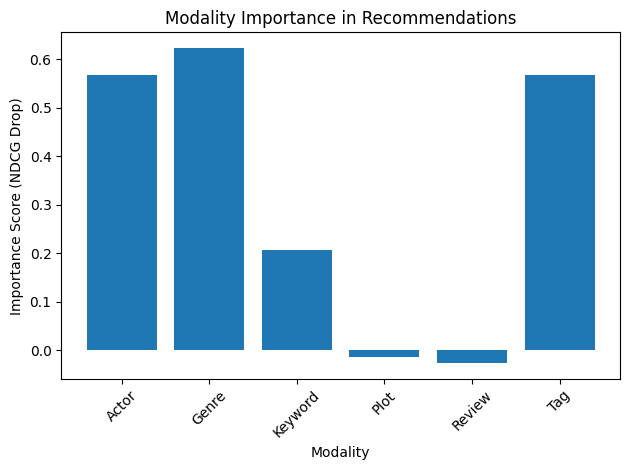

In [15]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt

# # Load data
ratings = pd.read_csv("ratings_small.csv").values
actor = pd.read_csv("Actor_small.csv").values
genre = pd.read_csv("Genre_small.csv").values
keyword = pd.read_csv("Keyword_small.csv").values
plot = pd.read_csv("Plot_small.csv").values
review = pd.read_csv("Review_small.csv").values
tag = pd.read_csv("Tag_small.csv").values

# ratings = pd.read_csv("ratings_converted.csv").values
# actor = pd.read_csv("Actor.csv", header=None).values   # (3706, n_features)
# genre = pd.read_csv("Genre.csv", header=None).values
# keyword = pd.read_csv("Keyword.csv", header=None).values
# plot = pd.read_csv("Plot.csv", header=None).values
# review = pd.read_csv("Review.csv", header=None).values
# tag = pd.read_csv("Tag.csv", header=None).values
print(actor.shape)
print(actor.shape)

# Split data into train, validation, and test sets (60-20-20 split)
from sklearn.model_selection import train_test_split
Xu_full, Xu_val = train_test_split(ratings, test_size=0.2, random_state=42)
Xu_train, Xu_test = train_test_split(Xu_full, test_size=0.25, random_state=42)  # 60% train, 20% val, 20% test
Xu_train = csr_matrix(Xu_train)
Xu_val = csr_matrix(Xu_val)
Xu_test = csr_matrix(Xu_test)
print("Xu_train shape:", Xu_train.shape)
print("Xu_val shape:", Xu_val.shape)
print("Xu_test shape:", Xu_test.shape)

param = {
    "debug": True,
    "Init": True,
    "maxItr": 50,
    "n_anchors": 80,
    "t": 6,
    "lambda": 0.9,
    "omega": 0.01,
    "alpha": 0.1,
    "beta": 0.1,
    "gamma": 0.1
}

Ntrain = actor.shape[0]  # 100 items
sample = np.random.choice(Ntrain, param["n_anchors"], replace=False)
anchorA = actor[sample]
anchorG = genre[sample]
anchorK = keyword[sample]
anchorP = plot[sample]
anchorR = review[sample]
anchorT = tag[sample]

def compute_similarity(data, anchors, sigma):
    return np.exp(-cdist(data, anchors, 'sqeuclidean') / (2 * sigma ** 2))

sigma_values = {"A": 0.2, "G": 3, "K": 0.3, "P": 0.3, "R": 0.3, "T": 7}
PhaA = np.hstack([compute_similarity(actor, anchorA, sigma_values["A"]), np.ones((Ntrain, 1))])
PhgG = np.hstack([compute_similarity(genre, anchorG, sigma_values["G"]), np.ones((Ntrain, 1))])
PhkK = np.hstack([compute_similarity(keyword, anchorK, sigma_values["K"]), np.ones((Ntrain, 1))])
PhpP = np.hstack([compute_similarity(plot, anchorP, sigma_values["P"]), np.ones((Ntrain, 1))])
PhrR = np.hstack([compute_similarity(review, anchorR, sigma_values["R"]), np.ones((Ntrain, 1))])
PhtT = np.hstack([compute_similarity(tag, anchorT, sigma_values["T"]), np.ones((Ntrain, 1))])

# Update the BMMF call to capture importance_scores
B, C, D, X, Y, Z, mu1, mu2, mu3, mu4, mu5, mu6, importance_scores = BMMF(PhaA, PhgG, PhkK, PhpP, PhrR, PhtT, Xu_train, 8, param, Xu_val=Xu_val)

k = 20
if not isinstance(Xu_test, np.ndarray):
    Xu_test = Xu_test.toarray()
Xu_test = Xu_test.T  # (200, 100) -> (100, 200)
ndcg = rating_metric(Xu_test, D.T, B.T, k, r=8)
print(f'Test NDCG: {np.mean(ndcg):.4f}')

# Visualize modality importance
modality_names = ['Actor', 'Genre', 'Keyword', 'Plot', 'Review', 'Tag']
importance_values = [importance_scores[name]*100 for name in modality_names]

plt.bar(modality_names, importance_values)
plt.title('Modality Importance in Recommendations')
plt.xlabel('Modality')
plt.ylabel('Importance Score (NDCG Drop)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

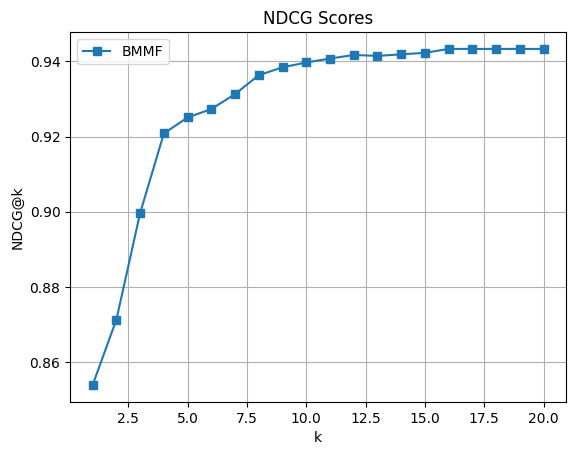

In [16]:

plt.plot(range(1, 21), ndcg, marker='s', label='BMMF')
plt.xlabel('k')
plt.ylabel('NDCG@k')
plt.title('NDCG Scores')
plt.grid(True)
plt.legend()
plt.show()

**DFM**

In [18]:

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack, find
from scipy.sparse.linalg import svds
from scipy.linalg import pinv
import matplotlib.pyplot as plt

# Load and preprocess data (equivalent to test.m)
def load_data(use_small_dataset=False):
    # if use_small_dataset:
    #     ratings_file = "ratings_small.csv"
    # else:
    ratings_file = "ratings_small.csv"

    # Read ratings as in BMMF
    ratings = pd.read_csv(ratings_file).values
    #ratings = ratings / 5.0  # Normalize as in MATLAB and BMMF

    # Debugging: Print ratings shape and sample
    # print(f"Ratings shape: {ratings.shape}")
    # print(f"Ratings sample (first 5 rows, first 5 cols):\n{ratings[:5, :5]}")

    # Split into train and test using divide_data2 from BMMF
    Xu_train, Xu_test = divide_data2(ratings)
    Xu_train = Xu_train.T  # Shape: (items, users)
    Xu_test = Xu_test.T

    # Debugging: Print train/test shapes
    # print(f"Xu_train shape: {Xu_train.shape}, non-zeros: {Xu_train.nnz}")
    # print(f"Xu_test shape: {Xu_test.shape}, non-zeros: {Xu_test.nnz}")

    # Extract sparse matrices (userX, itemX, y)
    I, J, y = find(Xu_train.T)  # userId, itemId, ratings
    num = len(y)
    userX = csr_matrix((np.ones(num), (np.arange(num), I)), shape=(num, Xu_train.shape[1]))
    itemX = csr_matrix((np.ones(num), (np.arange(num), J)), shape=(num, Xu_train.shape[0]))

    # Test set
    I2, J2, y2 = find(Xu_test.T)
    num2 = len(y2)
    userX2 = csr_matrix((np.ones(num2), (np.arange(num2), I2)), shape=(num2, Xu_test.shape[1]))
    itemX2 = csr_matrix((np.ones(num2), (np.arange(num2), J2)), shape=(num2, Xu_test.shape[0]))

    return userX, itemX, y, Xu_train, userX2, itemX2, y2, Xu_test

# DFMinit (adapted from DFMinit.m)
def DFMinit(userX, itemX, y, k, alpha, beta, option):
    unum = userX.shape[1]  # Number of users
    inum = itemX.shape[1]  # Number of items
    X = hstack([userX, itemX])  # Concatenate userX, itemX

    # Initialize matrices
    np.random.seed(42)
    w0 = np.random.rand()
    w = np.random.rand(unum + inum)
    userV = np.random.rand(k, unum)
    itemV = np.random.rand(k, inum)
    userZ = UpdateSVD(userV)
    itemZ = UpdateSVD(itemV)

    maxItr = option.get('maxItr', 5)
    tol = 1e-5

    # if option.get('debug', False):
    #     print("Starting DFMinit...")
    #     loss, obj = DFMinitobj(userX, itemX, y, k, alpha, beta, w0, w, userV, itemV, userZ, itemZ)
    #     print(f"loss value = {loss:.4f}, obj value = {obj:.4f}")

    converge = False
    it = 1
    p = ScaleScore(y, 2 * k, maxS=1, minS=0)
    userId, _, _ = find(userX.T)
    itemId, _, _ = find(itemX.T)

    while not converge:
        userV0 = userV.copy()
        itemV0 = itemV.copy()
        p1 = p - w0 - X @ w

        # Optimize userV
        for u in range(unum):
            rated_items = itemId[userId == u]
            if len(rated_items) == 0:
                continue
            D = itemV[:, rated_items]
            pu = p1[userId == u]
            Q = D @ D.T + beta * len(pu) * np.eye(k)
            L = D @ pu + beta * userZ[:, u]
            userV[:, u] = pinv(Q) @ L

        # Optimize itemV
        for i in range(inum):
            rated_users = userId[itemId == i]
            if len(rated_users) == 0:
                continue
            D = userV[:, rated_users]
            pi = p1[itemId == i]
            Q = D @ D.T + beta * len(pi) * np.eye(k)
            L = D @ pi + beta * itemZ[:, i]
            itemV[:, i] = pinv(Q) @ L

        # Optimize userZ, itemZ
        userZ = UpdateSVD(userV)
        itemZ = UpdateSVD(itemV)

        # Optimize w0 and w
        p2 = p.copy()
        for m in range(len(p)):
            p2[m] -= userV[:, userId[m]].T @ itemV[:, itemId[m]]
        D = hstack([csr_matrix(np.ones((len(y), 1))), userX, itemX])
        Q = D.T @ D + alpha * csr_matrix(np.eye(unum + inum + 1)) + 1e-6 * csr_matrix(np.eye(unum + inum + 1))
        L = D.T @ p2
        w_full = np.linalg.solve(Q.toarray(), L)
        w0 = w_full[0]
        w = w_full[1:]

        # if option.get('debug', False):
        #     print(f"DFMinit iteration: {it}")
        #     loss, obj = DFMinitobj(userX, itemX, y, k, alpha, beta, w0, w, userV, itemV, userZ, itemZ)
        #     print(f"loss value = {loss:.4f}, obj value = {obj:.4f}")

        if (it >= maxItr or
            max([np.linalg.norm(userV0 - userV, 'fro'),
                 np.linalg.norm(itemV0 - itemV, 'fro')]) < max([unum, inum]) * tol):
            converge = True
        it += 1

    return w0, w, userV, itemV, userZ, itemZ

# DFMinitobj (adapted from DFMinitobj.m)
def DFMinitobj(userX, itemX, y, k, alpha, beta, w0, w, userV, itemV, userZ, itemZ):
    X = hstack([userX, itemX])
    V = np.hstack([userV, itemV])
    Z = np.hstack([userZ, itemZ])
    userId, _, _ = find(userX.T)
    itemId, _, _ = find(itemX.T)

    p = ScaleScore(y, 2 * k, maxS=1, minS=0)
    p = p - w0 - X @ w
    for m in range(len(y)):
        p[m] -= userV[:, userId[m]].T @ itemV[:, itemId[m]]

    loss = p.T @ p
    no = np.linalg.norm(V, 'fro')
    obj = loss + alpha * w.T @ w + beta * np.trace(V @ Z.T)

    return loss, obj

# DFM (adapted from DFM.m)
def DFM(userX, itemX, y, k, alpha, beta, option):
    unum = userX.shape[1]
    inum = itemX.shape[1]
    X = hstack([userX, itemX])
    userId, _, _ = find(userX.T)
    itemId, _, _ = find(itemX.T)

    maxItr = option.get('maxItr', 5)
    maxItr2 = 5

    # Initialize with DFMinit
    w0, w, userV, itemV, userZ, itemZ = DFMinit(userX, itemX, y, k, alpha, beta, option)

    # Binary matrices
    userU = np.sign(userV)
    userU[userU == 0] = 1
    itemU = np.sign(itemV)
    itemU[itemU == 0] = 1

    if option.get('debug', False):
        print("Starting DFM...")
        loss, obj = DFMobj(userX, itemX, y, k, alpha, beta, w0, w, userU, itemU, userZ, itemZ)
        #print(f"loss value = {loss:.4f}, obj value = {obj:.4f}")

    converge = False
    it = 1
    p = ScaleScore(y, 2 * k, maxS=1, minS=0)

    while not converge:
        userU0 = userU.copy()
        itemU0 = itemU.copy()
        p1 = p - w0 - X @ w

        # Optimize userU
        for u in range(unum):
            rated_items = itemId[userId == u]
            if len(rated_items) == 0:
                continue
            uu = userU[:, u].copy()
            D = itemU[:, rated_items]
            pu = p1[userId == u]
            userU[:, u] = DCDmex(uu, D @ D.T, D @ pu, beta * userZ[:, u], maxItr2)

        # Optimize itemU
        for i in range(inum):
            rated_users = userId[itemId == i]
            if len(rated_users) == 0:
                continue
            iu = itemU[:, i].copy()
            D = userU[:, rated_users]
            pi = p1[itemId == i]
            itemU[:, i] = DCDmex(iu, D @ D.T, D @ pi, beta * itemZ[:, i], maxItr2)

        # Optimize userZ, itemZ
        userZ = UpdateSVD(userU)
        itemZ = UpdateSVD(itemU)

        # Optimize w
        p2 = p.copy()
        for m in range(len(p2)):
            p2[m] -= userU[:, userId[m]].T @ itemU[:, itemId[m]]
        D = hstack([csr_matrix(np.ones((len(y), 1))), userX, itemX])
        Q = D.T @ D + alpha * csr_matrix(np.eye(unum + inum + 1)) + 1e-6 * csr_matrix(np.eye(unum + inum + 1))
        L = D.T @ p2
        w_full = np.linalg.solve(Q.toarray(), L)
        w0 = w_full[0]
        w = w_full[1:]

        # if option.get('debug', False):
        #     print(f"DFM at bit {k}, Iteration: {it}")
        #     loss, obj = DFMobj(userX, itemX, y, k, alpha, beta, w0, w, userU, itemU, userZ, itemZ)
        #     print(f"loss value = {loss:.4f}, obj value = {obj:.4f}")

        if (it >= maxItr or
            (np.sum(userU != userU0) == 0 and
             np.sum(itemU != itemU0) == 0)):
            converge = True
        it += 1

    return w0, w, userU, itemU, userZ, itemZ

# DFMobj (adapted from DFMobj.m)
def DFMobj(userX, itemX, y, k, alpha, beta, w0, w, userU, itemU, userZ, itemZ):
    X = hstack([userX, itemX])
    U = np.hstack([userU, itemU])
    Z = np.hstack([userZ, itemZ])
    userId, _, _ = find(userX.T)
    itemId, _, _ = find(itemX.T)

    p = ScaleScore(y, 2 * k, maxS=1, minS=0)
    p = p - w0 - X @ w
    for m in range(len(y)):
        p[m] -= userU[:, userId[m]].T @ itemU[:, itemId[m]]

    loss = p.T @ p
    obj = loss + alpha * w.T @ w + beta * np.trace(U @ Z.T)

    return loss, obj

# NDCG (adapted from MATLAB's NDCG)
def NDCG(userX, itemX, y, kvalue, w0, w, userU, itemU):
    X = hstack([userX, itemX])
    userId, _, _ = find(userX.T)
    itemId, _, _ = find(itemX.T)

    # Compute predictions
    pred = np.zeros(len(y))
    for m in range(len(y)):
        pred[m] = (w0 + X[m, :] @ w + userU[:, userId[m]].T @ itemU[:, itemId[m]]).item()

    # Debugging: Print predictions and actual ratings
    # print("Predictions sample:", pred[:5])
    # print("Actual ratings sample:", y[:5])

    # Group by user
    unique_users = np.unique(userId)
    dcg = 0.0
    idcg = 0.0
    count = 0

    for u in unique_users:
        idx = np.where(userId == u)[0]
        if len(idx) <= 1:
            continue

        actual = y[idx]
        predicted = pred[idx]

        # Sort actual ratings for IDCG
        order = np.argsort(-actual)
        sorted_actual = actual[order]
        ideal_rel = sorted_actual[:min(kvalue, len(sorted_actual))]
        if len(ideal_rel) > 0:
            idcg += sum((2**rel - 1) / np.log2(i + 2) for i, rel in enumerate(ideal_rel))

        # Sort predicted ratings for DCG
        order = np.argsort(-predicted)
        sorted_actual = actual[order]
        rel = sorted_actual[:min(kvalue, len(sorted_actual))]
        if len(rel) > 0:
            dcg += sum((2**rel - 1) / np.log2(i + 2) for i, rel in enumerate(rel))

        count += 1

    return dcg / idcg if idcg > 0 and count > 0 else 0

# Main execution (equivalent to test.m)
def main(use_small_dataset=False):
    # Load data
    userX, itemX, y, Xu_train, userX2, itemX2, y2, Xu_test = load_data(use_small_dataset)

    # Parameters
    k = 8
    alpha = 1
    beta = 0.1
    option = {
        'init': True,
        'debug': True,
        'maxItr': 5
    }

    # Run DFM
    w0, w, userU, itemU, userZ, itemZ = DFM(userX, itemX, y, k, alpha, beta, option)

    # Debugging: Print latent factors
    # print("userU sample:", userU[:, :5])
    # print("itemU sample:", itemU[:, :5])

    # Evaluate NDCG
    ndcg_DFM = np.zeros(20)
    for kvalue in range(1, 21):
        ndcg_value = NDCG(userX2, itemX2, y2, kvalue, w0, w, userU, itemU)
        ndcg_DFM[kvalue - 1] = ndcg_value
    return ndcg_DFM


if __name__ == "__main__":
   ndcg_DFM = main(use_small_dataset=True)  # Use smaller dataset for consistency with BMMF



Starting DFM...


The BMMF ndcg is 0.9284
The DFM ndcg is 0.9243


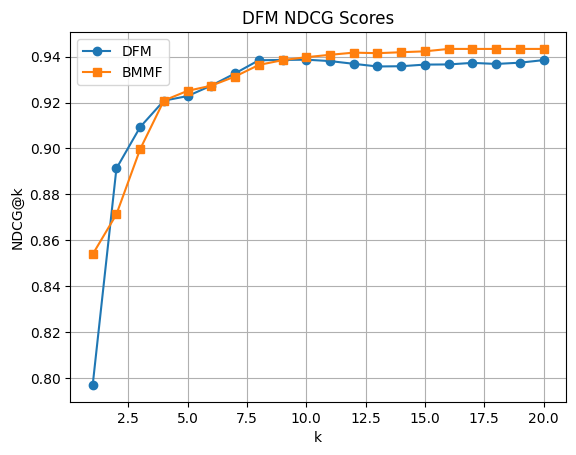

In [19]:
print(f"The BMMF ndcg is {np.mean(ndcg):.4f}")
print(f"The DFM ndcg is {np.mean(ndcg_DFM):.4f}")
# Plot NDCG
plt.plot(range(1, 21), ndcg_DFM, marker='o', label='DFM')
plt.plot(range(1, 21), ndcg, marker='s', label='BMMF')
plt.xlabel('k')
plt.ylabel('NDCG@k')
plt.title('DFM NDCG Scores')
plt.grid(True)
plt.legend()
plt.show()

In [13]:
# import numpy as np
# import pandas as pd
# from scipy.sparse import csr_matrix

# # Load original data
# ratings = pd.read_csv("ratings_converted.csv").values
# actor = pd.read_csv("Actor.csv").values
# genre = pd.read_csv("Genre.csv").values
# keyword = pd.read_csv("Keyword.csv").values
# plot = pd.read_csv("Plot.csv").values
# review = pd.read_csv("Review.csv").values
# tag = pd.read_csv("Tag.csv").values

# # Define smaller dataset sizes
# n_users_small = 200  # Target number of users
# n_items_small = 100  # Target number of items

# # Step 1: Sample items with non-zero ratings
# item_nonzero_counts = (ratings > 0).sum(axis=0)  # Count non-zero ratings per item
# valid_items = np.where(item_nonzero_counts > 0)[0]  # Items with at least one rating
# np.random.seed(42)  # For reproducibility
# sampled_item_indices = np.random.choice(valid_items, size=min(n_items_small, len(valid_items)), replace=False)

# # Step 2: Sample users with non-zero ratings for the selected items
# ratings_subset_items = ratings[:, sampled_item_indices]  # Subset ratings to sampled items
# user_nonzero_counts = (ratings_subset_items > 0).sum(axis=1)  # Count non-zero ratings per user
# valid_users = np.where(user_nonzero_counts > 0)[0]  # Users with at least one rating for sampled items
# sampled_user_indices = np.random.choice(valid_users, size=min(n_users_small, len(valid_users)), replace=False)

# # Step 3: Create smaller datasets
# ratings_small = ratings[np.ix_(sampled_user_indices, sampled_item_indices)]  # Subset ratings
# actor_small = actor[sampled_item_indices, :]
# genre_small = genre[sampled_item_indices, :]
# keyword_small = keyword[sampled_item_indices, :]
# plot_small = plot[sampled_item_indices, :]
# review_small = review[sampled_item_indices, :]
# tag_small = tag[sampled_item_indices, :]

# # Step 4: Apply keep_top_k_values (if needed, adjust k for smaller size)
# k = 10  # Smaller k since we have fewer items
# actor_small = keep_top_k_values(actor_small, k)
# genre_small = keep_top_k_values(genre_small, k)
# keyword_small = keep_top_k_values(keyword_small, k)
# plot_small = keep_top_k_values(plot_small, k)
# review_small = keep_top_k_values(review_small, k)
# tag_small = keep_top_k_values(tag_small, k)

# # Step 5: Verify shapes
# print("ratings_small shape:", ratings_small.shape)  # Should be (200, 100)
# print("actor_small shape:", actor_small.shape)    # Should be (100, n_features_actor)
# print("genre_small shape:", genre_small.shape)    # Should be (100, n_features_genre)
# print("keyword_small shape:", keyword_small.shape)
# print("plot_small shape:", plot_small.shape)
# print("review_small shape:", review_small.shape)
# print("tag_small shape:", tag_small.shape)

# # Step 6: Save smaller datasets (optional)
# pd.DataFrame(ratings_small).to_csv("ratings_small.csv", index=False)
# pd.DataFrame(actor_small).to_csv("Actor_small.csv", index=False)
# pd.DataFrame(genre_small).to_csv("Genre_small.csv", index=False)
# pd.DataFrame(keyword_small).to_csv("Keyword_small.csv", index=False)
# pd.DataFrame(plot_small).to_csv("Plot_small.csv", index=False)
# pd.DataFrame(review_small).to_csv("Review_small.csv", index=False)
# pd.DataFrame(tag_small).to_csv("Tag_small.csv", index=False)

# # Step 7: Update your main code to use the smaller dataset
# Xu_train_small, Xu_test_small = divide_data2(ratings_small)
# print("Xu_train_small shape:", Xu_train_small.shape)

ratings_small shape: (200, 100)
actor_small shape: (100, 16)
genre_small shape: (100, 23)
keyword_small shape: (100, 16)
plot_small shape: (100, 16)
review_small shape: (100, 16)
tag_small shape: (100, 16)
Xu_train_small shape: (200, 100)


In [ ]:
print("Xu_test shape:", Xu_test.shape)
print("Xu_train shape:", Xu_train.shape)

Xu_test shape: (3706, 6039)
Xu_train shape: (3706, 6039)
